Example of running the LEMBAS model on macrophage data.

In [1]:
import os

import numpy as np
import pandas as pd

from scipy.stats import pearsonr
import torch

import plotnine as p9

lembas_path = '/home/hmbaghda/Projects/LEMBAS'
import sys
sys.path.insert(1, os.path.join(lembas_path))
from LEMBAS.model.bionetwork import format_network, SignalingModel
from LEMBAS.model.train import train_signaling_model
import LEMBAS.utilities as utils
from LEMBAS import plotting, io

/tmp/ipykernel_39487/3121986289.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
n_cores = 12
utils.set_cores(n_cores)

seed = 888
if seed:
    torch.use_deterministic_algorithms(True)
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    utils.set_seeds(seed = seed)

device = "cuda" if torch.cuda.is_available() else "cpu"
data_path = './macrophage_data'

# Build the Model

## Load Input Data

In [3]:
# prior knowledge signaling network
net = pd.read_csv(os.path.join(data_path, 'macrophage-Model.tsv'), sep = '\t', index_col = False)

# ligand input and TF output
ligand_input = pd.read_csv(os.path.join(data_path, 'macrophage-Ligands.tsv'), sep='\t', low_memory=False, index_col=0)
tf_output = pd.read_csv(os.path.join(data_path, 'macrophage-TFs.tsv'), sep='\t', low_memory=False, index_col=0)

Let's see what the signaling network looks like:

In [4]:
stimulation_label = 'stimulation'
inhibition_label = 'inhibition'
weight_label = 'mode_of_action'
source_label = 'source'
target_label = 'target'

net[[source_label, target_label, stimulation_label, inhibition_label]].head()

,source,target,stimulation,inhibition
0,P49137,Q16539,0,0
1,Q16539,P49137,1,0
2,P31749,O15111,1,0
3,O15111,P19838,1,0
4,P19838,O15111,0,0


Let's format it to fit with the necessary inputs to the SignalingModel:

In [5]:
net = format_network(net, weight_label = weight_label, stimulation_label = stimulation_label, inhibition_label = inhibition_label)
net[[source_label, target_label, weight_label, stimulation_label, inhibition_label]].head()

,source,target,mode_of_action,stimulation,inhibition
0,P49137,Q16539,0.1,0,0
1,Q16539,P49137,1.0,1,0
2,P31749,O15111,1.0,1,0
3,O15111,P19838,1.0,1,0
4,P19838,O15111,0.1,0,0


# Define Parameters to Build and Train Model

In [6]:
# linear scaling of inputs/outputs
projection_amplitude_in = 3
projection_amplitude_out = 1.2
# other parameters
bionet_params = {'target_steps': 100, 'max_steps': 150, 'exp_factor':50, 'tolerance': 1e-5, 'leak':1e-2} # fed directly to model

# training parameters
lr_params = {'max_iter': 5000, 
             'learning_rate': 2e-3}
other_params = {'batch_size': 32, 'noise_level': 10, 'gradient_noise_level': 1e-9}
regularization_params = {'param_lambda_L2': 1e-6, 'moa_lambda_L1': 0.1, 'ligand_lambda_L2': 1e-5, 'uniform_lambda_L2': 1e-4, 
                   'uniform_max': 1/projection_amplitude_out, 'spectral_loss_factor': 1e-5}
spectral_radius_params = {'n_probes_spectral': 5, 'power_steps_spectral': 50, 'subset_n_spectral': 10}
target_spectral_radius = 0.8
hyper_params = {**lr_params, **other_params, **regularization_params, **spectral_radius_params} # fed into training function

## Initialize Model
Next, let's initialize the model and format the inputs/outputs for running the model:

In [7]:
mod = SignalingModel(net = net,
                     X_in = ligand_input,
                     y_out = tf_output, 
                     projection_amplitude_in = projection_amplitude_in, projection_amplitude_out = projection_amplitude_out,
                     weight_label = weight_label, source_label = source_label, target_label = target_label,
                     bionet_params = bionet_params, 
                     dtype = torch.float32, device = device, seed = seed)

The ligand input, after filtering for nodes in the network, looks like this:

In [8]:
mod.X_in.head()

,Ligand_GC,Ligand_IC,Ligand_IFNb,Ligand_IFNg,Ligand_IL10,Ligand_IL13,Ligand_IL4,Ligand_LPSc,Ligand_P3C,Ligand_PGE2,Ligand_TNFa,Ligand_upLPS
CON,0,0,0,0,0,0,0,0,0,0,0,0
GC,1,0,0,0,0,0,0,0,0,0,0,0
IFNb,0,0,1,0,0,0,0,0,0,0,0,0
IFNb+TNFa+PGE2+P3C,0,0,1,0,0,0,0,0,1,1,1,0
IFNb+TNFa+PGE2+P3C+IFNg,0,0,1,1,0,0,0,0,1,1,1,0


The TF activity output, after filtering for nodes in the network, looks like this:

In [9]:
mod.y_out.head()

,O43524,O75030,P01100,P01106,P03372,P04637,P05412,P08047,P10070,P10242,...,Q07869,Q08050,Q12778,Q13127,Q13485,Q14186,Q16665,Q9H3D4,Q9NQB0,Q9UJU2
CON,0.543487,0.506355,0.288705,0.524944,0.508840,0.535930,0.456016,0.799885,0.465701,0.407298,...,0.479674,0.404891,0.409449,0.568049,0.439274,0.702048,0.450063,0.147630,0.384904,0.677774
GC,0.677927,0.617778,0.119494,0.724938,0.613868,0.796771,0.011826,0.439144,0.421594,0.677585,...,0.299406,0.103314,0.656781,0.440104,0.544396,0.482236,0.094289,0.250332,0.209280,0.637135
IFNb,0.384689,0.621748,0.109474,0.352545,0.558823,0.512618,0.187316,0.326541,0.430194,0.573846,...,0.505945,0.732870,0.513355,0.429696,0.509111,0.545478,0.131642,0.557754,0.465558,0.649616
IFNb+TNFa+PGE2+P3C,0.894344,0.618304,0.815526,0.029120,0.789124,0.627074,0.393195,0.551965,0.399580,0.498236,...,0.241678,0.735164,0.709700,0.383326,0.503909,0.150867,0.736157,0.556562,0.390066,0.232772
IFNb+TNFa+PGE2+P3C+IFNg,0.757642,0.506760,0.772328,0.033346,0.645125,0.762146,0.619820,0.420949,0.406377,0.303368,...,0.088150,0.655950,0.762460,0.409982,0.199154,0.199775,0.818583,0.677592,0.346423,0.165553


A forward pass looks like this:

In [10]:
# X_in = mod.df_to_tensor(mod.X_in) # ligand inputs
# X_full = mod.input_layer(X_in) # ligand inputs in signaling network
# Y_full = mod.signaling_network(X_full) # signaling network weights
# Y_hat = mod.output_layer(Y_full) # TF outputs of signaling network

## Train Model

In [14]:
# model setup
mod.input_layer.weights.requires_grad = False # don't learn scaling factors for the ligand input concentrations
mod.signaling_network.prescale_weights(target_radius = target_spectral_radius) # spectral radius

# loss and optimizer
loss_fn = torch.nn.MSELoss(reduction='mean')
optimizer = torch.optim.Adam

# training loop
res = train_signaling_model(mod, optimizer, loss_fn,
                            reset_epoch = 200,
                            hyper_params = hyper_params,
                            train_split_frac = {'train': 0.8, 'test': 0.2, 'validation': None},
                            train_seed = seed,
                            verbose = True)
mod, cur_loss, cur_eig, mean_loss, stats, X_train, X_test, X_val, y_train, y_test, y_val = res

# store results
io.write_pickled_object(stats, os.path.join(data_path, 'training_stats.pickle'))
torch.save(obj=mod.state_dict(), f=os.path.join(data_path, 'mac_state_dict.pth'))

# Predict using the model:

In [12]:
mod.load_state_dict(torch.load(os.path.join(data_path, 'mac_state_dict.pth')))
stats = io.read_pickled_object(os.path.join(data_path, 'training_stats.pickle'))

In [13]:
mod.eval()
Y_hat, Y_full = mod(X_test)

# Visualize

Let's see how the various stats performed across training:

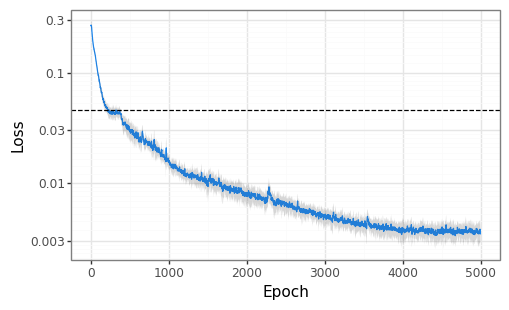

In [14]:
loss_smooth = utils.get_moving_average(values = stats['loss_mean'], n_steps = 5)
loss_sigma_smooth = utils.get_moving_average(values = stats['loss_sigma'], n_steps = 10)
epochs = np.array(range(stats['loss_mean'].shape[0]))

p1A = plotting.shade_plot(X = epochs, Y = loss_smooth, sigma = loss_sigma_smooth, x_label = 'Epoch', y_label = 'Loss')
p1A += p9.scale_y_log10()
p1A += p9.geom_hline(yintercept = mean_loss.item(), linetype="dashed", color="black")
p1A.draw()

As well as how the learning rate was adjusted across training:

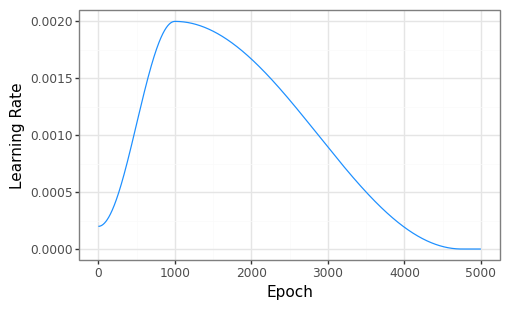

In [15]:
viz_df = pd.DataFrame(data = {'Epoch': epochs, 'lr': stats['learning_rate']})
width, height = 5, 3
p1B = (
    p9.ggplot(viz_df, p9.aes(x='Epoch', y = 'lr')) +
    p9.geom_line(color = '#1E90FF') +
    p9.theme_bw() + 
    p9.theme(figure_size=(width, height)) +
    p9.ylab('Learning Rate')
)
p1B.draw()

As well as the spectral radius:

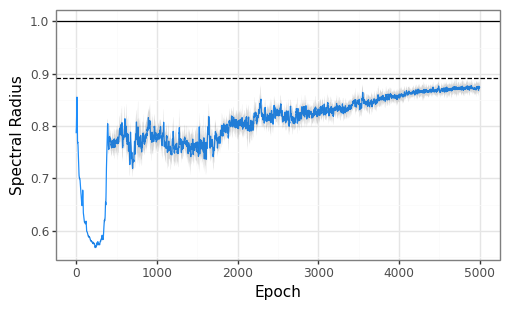

In [16]:
eig_smooth = utils.get_moving_average(stats['eig_mean'], 5)
eig_sigma_smooth = utils.get_moving_average(stats['eig_sigma'], 5)

p1C = plotting.shade_plot(X = epochs, Y = eig_smooth, sigma = eig_sigma_smooth, x_label = 'Epoch', y_label = 'Spectral Radius')
p1C += p9.geom_hline(yintercept = mod.signaling_network.training_params['spectral_target'], linetype="dashed", color="black")
p1C += p9.geom_hline(yintercept = 1, color="black")
p1C.draw()

Next, let's see what the correlation between the predicted and actual transcription factor is:

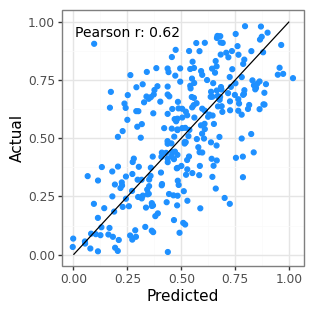

In [17]:
y_pred = Y_hat.detach().flatten().cpu().numpy()
y_actual = y_test.detach().flatten().cpu().numpy()

pr, _ = pearsonr(y_pred, y_actual)

viz_df = pd.DataFrame(data = {'Predicted': y_pred, 'Actual': y_actual})
width, height = 3, 3
p2 = (
    p9.ggplot() +
    p9.geom_point(data = viz_df, mapping = p9.aes(x='Predicted', y = 'Actual'), color = '#1E90FF') +
    p9.geom_line(data = pd.DataFrame(data = {'x': [0,1], 'y': [0, 1]}), mapping = p9.aes(x='x', y = 'y'), color = 'black') +
    p9.theme_bw() + 
    p9.theme(figure_size=(width, height)) +
    p9.annotate(geom = 'text', x=0.25, y = 0.95, label = 'Pearson r: {:.2f}'.format(pr), size = 10)
)
p2.draw()

Finally, let's see how our prediction error compares to error of the prediction relative to a control predicted on an input of no ligands. 

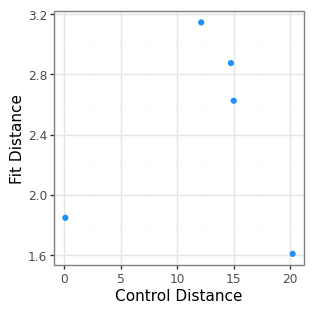

In [18]:
X_ctrl = torch.zeros((1, X_test.shape[1]), dtype=mod.dtype, device = mod.device)
Y_ctrl, _ = mod(X_ctrl)
signal_distance = torch.sum(torch.abs(Y_hat - Y_ctrl),dim=1).detach().cpu().numpy().flatten()
fit_distance = torch.sum(torch.square(Y_hat-y_test),dim=1).detach().cpu().numpy().flatten()


viz_df = pd.DataFrame(data = {'Control Distance': signal_distance, 'Fit Distance': fit_distance})
width, height = 3, 3
p3 = (
    p9.ggplot() +
    p9.geom_point(data = viz_df, mapping = p9.aes(x='Control Distance', y = 'Fit Distance'), color = '#1E90FF') +
    p9.theme_bw() + 
    p9.theme(figure_size=(width, height)) 
)
p3.draw()